Database successfully created and populated!

Rows in Engagements table: 111


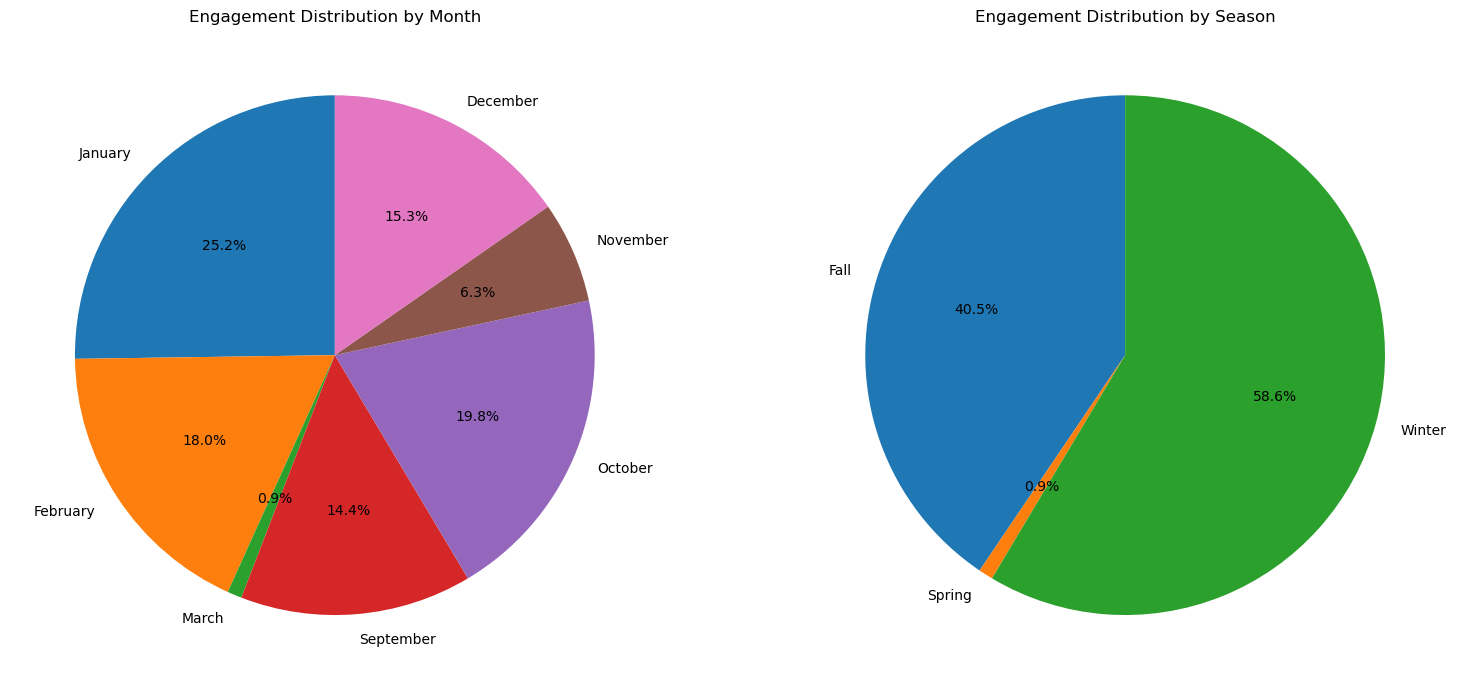

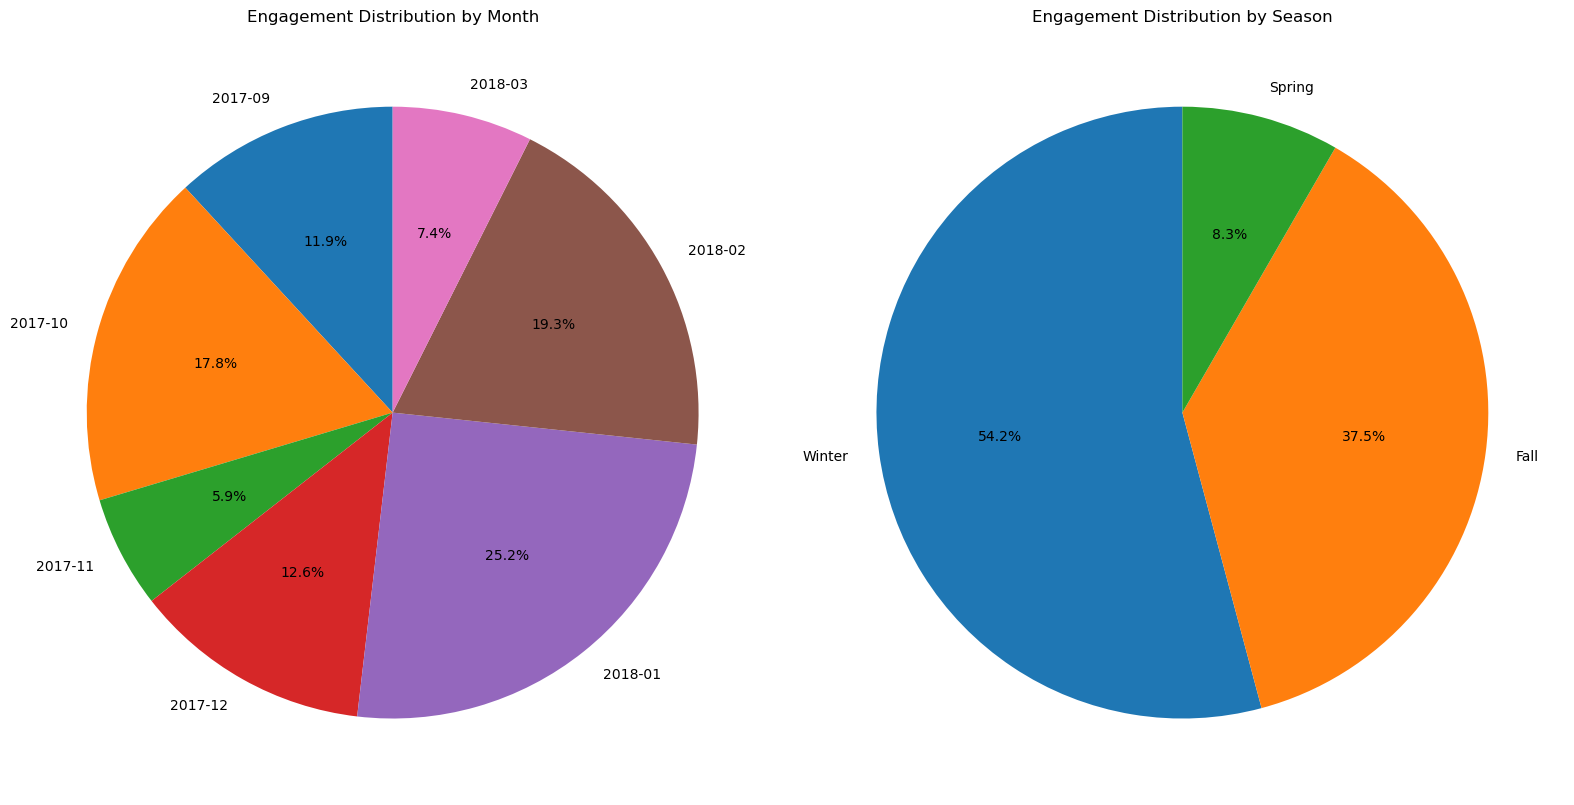


OUTLIER ENGAGEMENT:
   EngagementNumber   StartDate     EndDate  duration_days
0                99  2018-01-23  2018-02-23           32.0


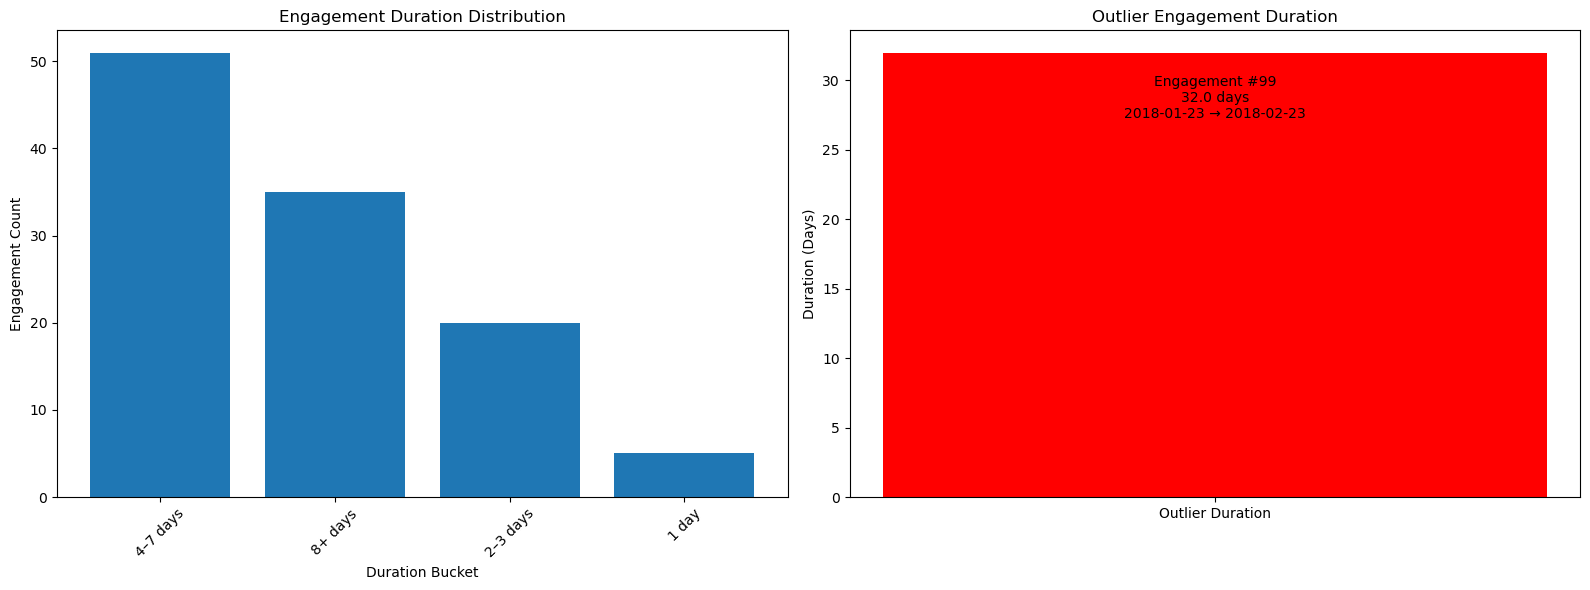

  day_type  active_day_count  avg_per_day
0  Weekend               178         89.0
1  Weekday               498         99.6


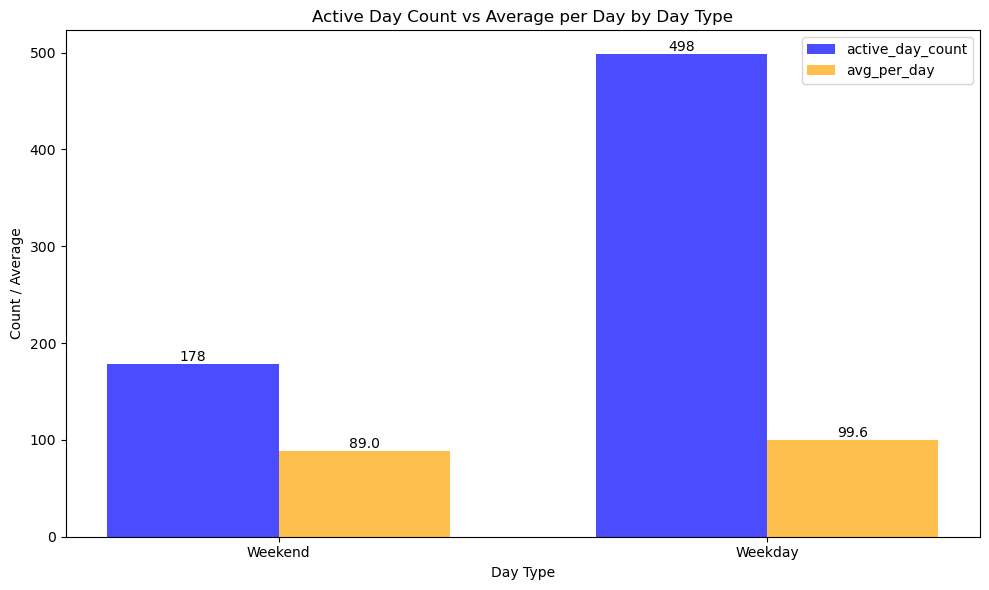

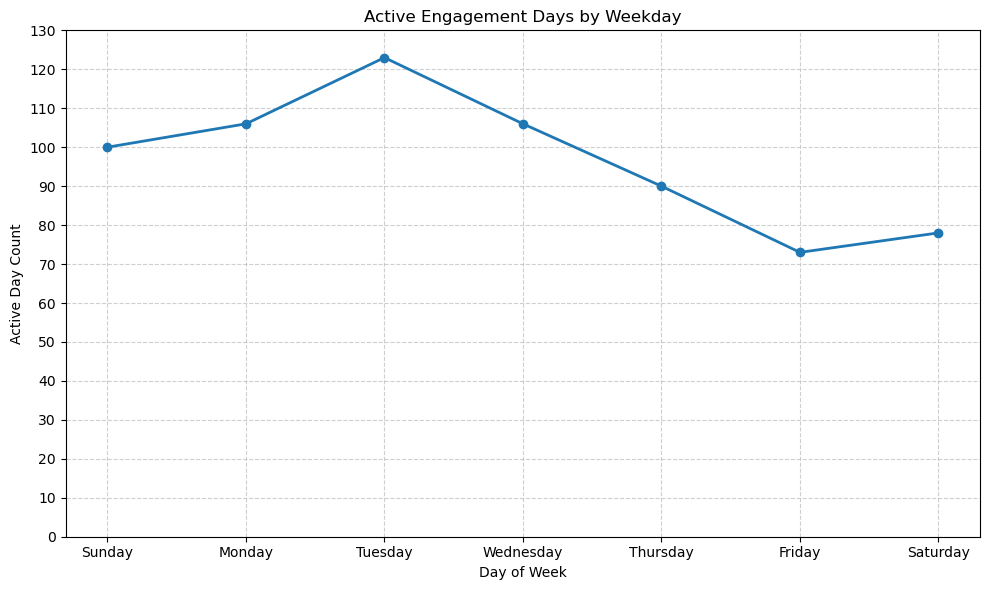

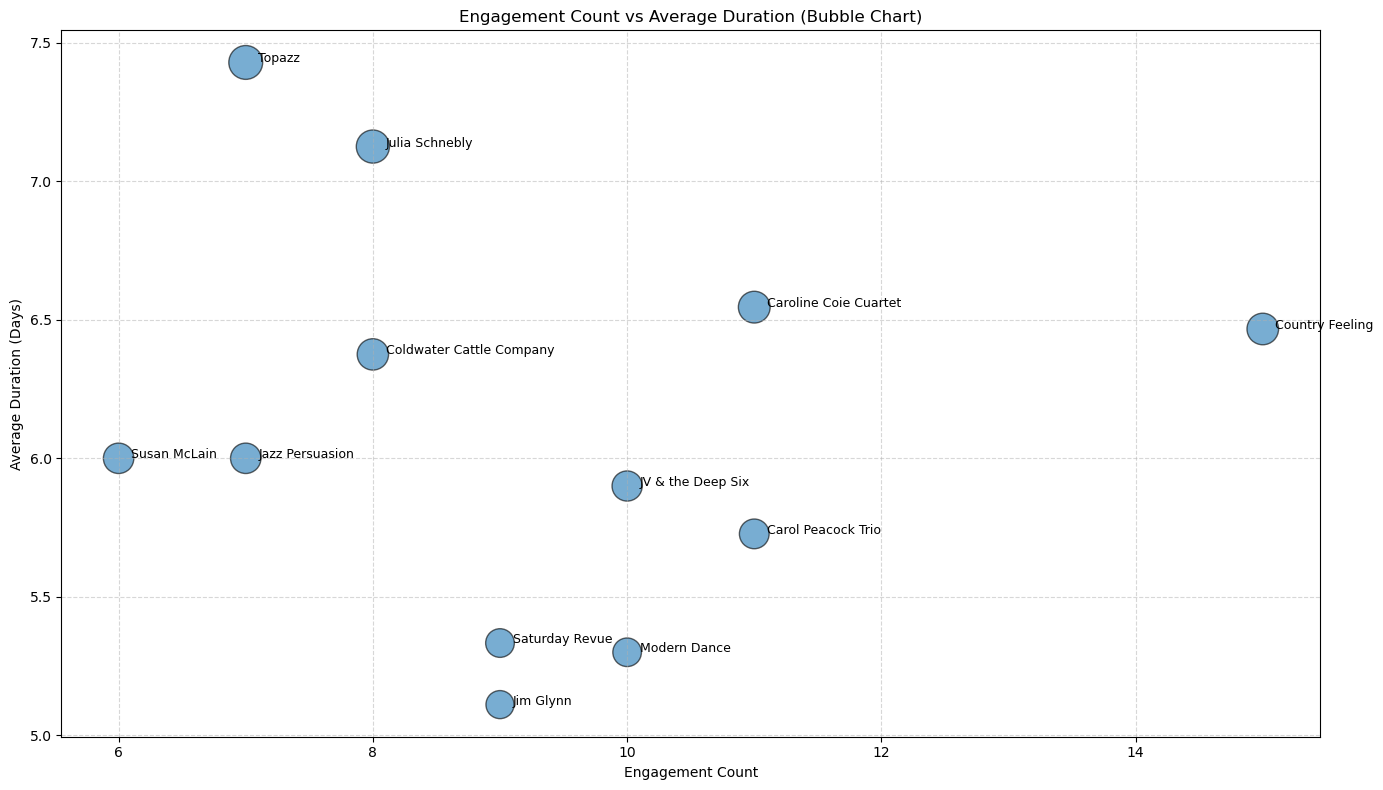

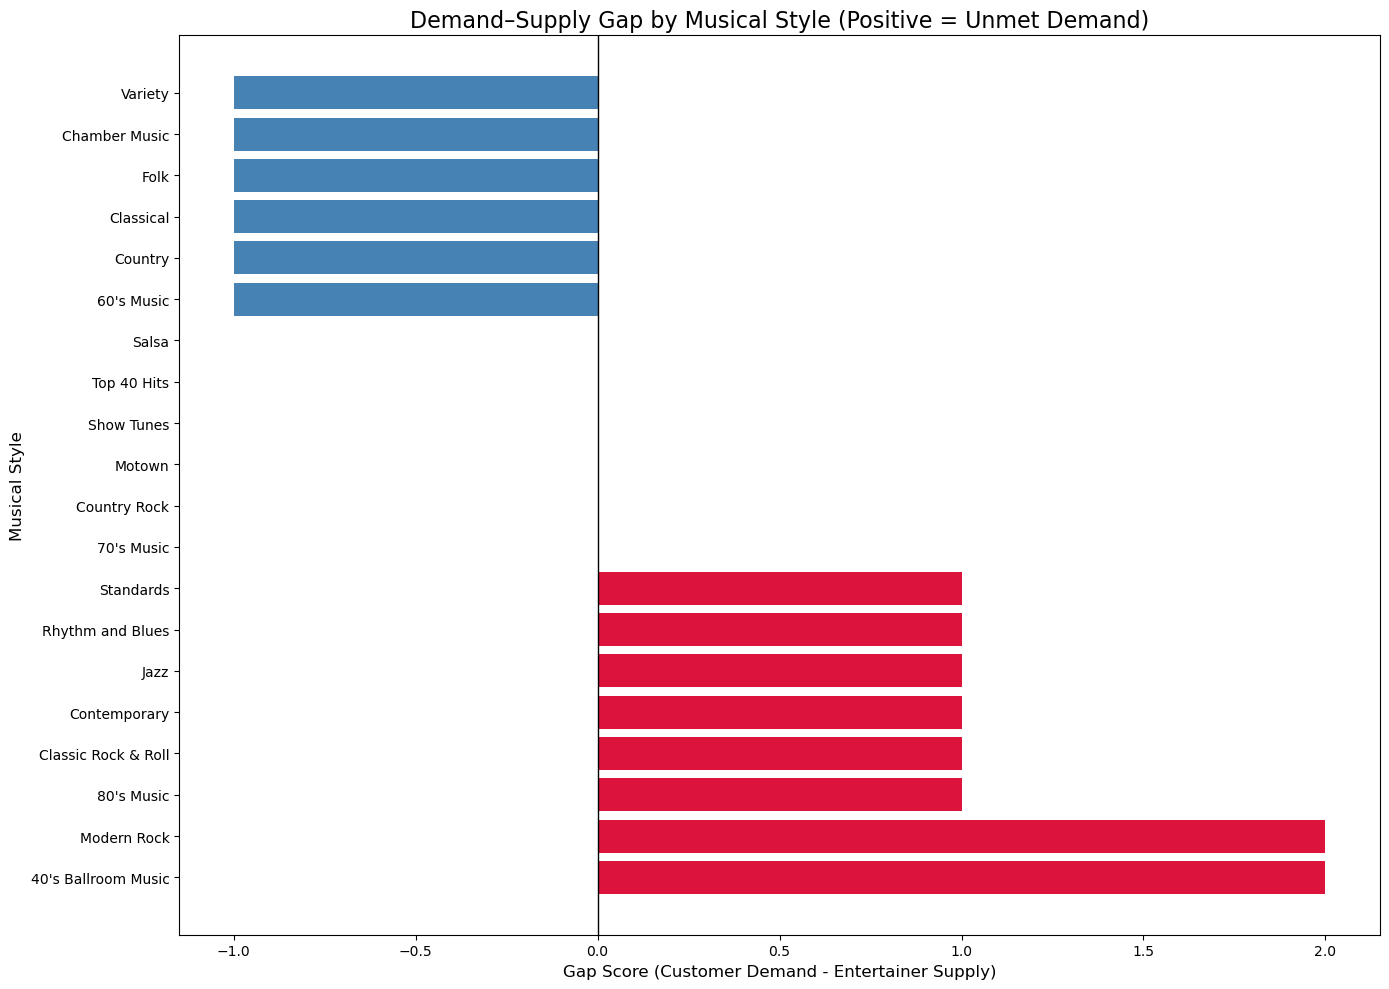

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import seaborn as sns

# ---------------------------------------------------------
# 1. CONNECT TO SQLITE & LOAD THE entertainment.sql FILE
# ---------------------------------------------------------
sql_file = "entertainment.sql"   

engine = create_engine("sqlite:///entertainment.db")

with engine.connect() as conn:
    with open(sql_file, "r", encoding="utf-8") as f:
        sql_script = f.read()
        conn.connection.executescript(sql_script)   


print("Database successfully created and populated!")

try:
    count_eng = pd.read_sql_query("SELECT COUNT(*) AS cnt FROM Engagements;", engine)
    print("\nRows in Engagements table:", count_eng['cnt'][0])
except:
    print("\nEngagements table not found! Your SQL file may be incompatible with SQLite.\n")


# Helper: Month number → Month name
month_map = {
    "01": "January", "02": "February", "03": "March",
    "04": "April", "05": "May", "06": "June",
    "07": "July", "08": "August", "09": "September",
    "10": "October", "11": "November", "12": "December"
}

# ---------------------------------------------------------
# 2A1. Engagements by Month — Pie Chart
# ---------------------------------------------------------
query_month = """
SELECT strftime('%m', StartDate) AS month_num,
       COUNT(*) AS popularity
FROM Engagements
WHERE StartDate IS NOT NULL
GROUP BY month_num
ORDER BY month_num;
"""

df_month = pd.read_sql_query(query_month, engine)
df_month["month"] = df_month["month_num"].map(month_map)

# ---------------------------------------------------------
# 2B1. Engagements by Season — Pie Chart
# ---------------------------------------------------------
query_season = """
SELECT 
CASE 
    WHEN strftime('%m', StartDate) IN ('12','01','02') THEN 'Winter'
    WHEN strftime('%m', StartDate) IN ('03','04','05') THEN 'Spring'
    WHEN strftime('%m', StartDate) IN ('06','07','08') THEN 'Summer'
    WHEN strftime('%m', StartDate) IN ('09','10','11') THEN 'Fall'
END AS season,
COUNT(*) AS popularity
FROM Engagements
WHERE StartDate IS NOT NULL
GROUP BY season
ORDER BY season;
"""

df_season = pd.read_sql_query(query_season, engine)

# ---------------------------------------------------------
# Plot Two Pie Charts Side-by-Side
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Pie Chart 1: Months ---
axes[0].pie(
    df_month["popularity"],
    labels=df_month["month"],
    autopct="%1.1f%%",
    startangle=90
)
axes[0].set_title("Engagement Distribution by Month")

# --- Pie Chart 2: Seasons ---
axes[1].pie(
    df_season["popularity"],
    labels=df_season["season"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Engagement Distribution by Season")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2A2. Engagements by Month — Pie Chart
# ---------------------------------------------------------
query_month = """
SELECT month, COUNT(*) AS popularity
FROM (
    SELECT DISTINCT EngagementNumber, strftime('%Y-%m', StartDate) AS month
    FROM Engagements
    WHERE StartDate IS NOT NULL

    UNION

    SELECT DISTINCT EngagementNumber, strftime('%Y-%m', EndDate) AS month
    FROM Engagements
    WHERE EndDate IS NOT NULL
) AS m
GROUP BY month
ORDER BY month;
"""

df_month = pd.read_sql_query(query_month, engine)

# ---------------------------------------------------------
# 2B2. SEASONS QUERY — FIXED FOR SQLITE
# ---------------------------------------------------------
query_season = """
SELECT season, COUNT(*) AS popularity_by_season
FROM (
    SELECT
        CASE
            WHEN strftime('%m', StartDate) IN ('12','01','02') THEN 'Winter'
            WHEN strftime('%m', StartDate) IN ('03','04','05') THEN 'Spring'
            WHEN strftime('%m', StartDate) IN ('06','07','08') THEN 'Summer'
            WHEN strftime('%m', StartDate) IN ('09','10','11') THEN 'Fall'
        END AS season,
        EngagementNumber
    FROM Engagements
    WHERE StartDate IS NOT NULL

    UNION

    SELECT
        CASE
            WHEN strftime('%m', EndDate) IN ('12','01','02') THEN 'Winter'
            WHEN strftime('%m', EndDate) IN ('03','04','05') THEN 'Spring'
            WHEN strftime('%m', EndDate) IN ('06','07','08') THEN 'Summer'
            WHEN strftime('%m', EndDate) IN ('09','10','11') THEN 'Fall'
        END AS season,
        EngagementNumber
    FROM Engagements
    WHERE EndDate IS NOT NULL
) AS combined
GROUP BY season
ORDER BY popularity_by_season DESC;
"""

df_season = pd.read_sql_query(query_season, engine)

# ---------------------------------------------------------
#  SIDE-BY-SIDE PIE CHARTS
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # 1 row, 2 columns

# ---------- LEFT PIE: MONTHS ----------
axes[0].pie(
    df_month["popularity"],
    labels=df_month["month"],
    autopct="%1.1f%%",
    startangle=90
)
axes[0].set_title("Engagement Distribution by Month")

# ---------- RIGHT PIE: SEASONS ----------
axes[1].pie(
    df_season["popularity_by_season"],
    labels=df_season["season"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Engagement Distribution by Season")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3 Engagement Duration Distribution
# ---------------------------------------------------------
query_duration = """
SELECT 
   CASE 
       WHEN (julianday(EndDate) - julianday(StartDate) + 1) = 1 THEN '1 day'
       WHEN (julianday(EndDate) - julianday(StartDate) + 1) BETWEEN 2 AND 3 THEN '2–3 days'
       WHEN (julianday(EndDate) - julianday(StartDate) + 1) BETWEEN 4 AND 7 THEN '4–7 days'
       ELSE '8+ days'
   END AS duration_bucket,
   COUNT(*) AS engagement_count
FROM Engagements
WHERE StartDate IS NOT NULL
  AND EndDate IS NOT NULL
GROUP BY duration_bucket
ORDER BY engagement_count DESC;
"""

df_duration = pd.read_sql_query(query_duration, engine)

# ---------------------------------------------------------
# OUTLIER QUERY — LONGEST ENGAGEMENT
# ---------------------------------------------------------
query_outlier = """
SELECT
   EngagementNumber,
   StartDate,
   EndDate,
   (julianday(EndDate) - julianday(StartDate) + 1) AS duration_days
FROM Engagements
WHERE StartDate IS NOT NULL AND EndDate IS NOT NULL
ORDER BY duration_days DESC
LIMIT 1;
"""

df_outlier = pd.read_sql_query(query_outlier, engine)

# Print outlier info
print("\nOUTLIER ENGAGEMENT:")
print(df_outlier)

# ---------------------------------------------------------
# VISUALIZATION: Duration Distribution + Outlier Highlight
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------- LEFT PLOT: NORMAL DISTRIBUTION --------
axes[0].bar(df_duration["duration_bucket"], df_duration["engagement_count"])
axes[0].set_title("Engagement Duration Distribution")
axes[0].set_xlabel("Duration Bucket")
axes[0].set_ylabel("Engagement Count")
axes[0].tick_params(axis='x', rotation=45)

# -------- RIGHT PLOT: OUTLIER --------
out = df_outlier.iloc[0]

axes[1].bar(
    ["Outlier Duration"],
    [out["duration_days"]],
    color="red"
)
axes[1].set_title("Outlier Engagement Duration")
axes[1].set_ylabel("Duration (Days)")

axes[1].text(
    0, out["duration_days"] * 0.95,
    f"Engagement #{out['EngagementNumber']}\n"
    f"{out['duration_days']} days\n"
    f"{out['StartDate']} → {out['EndDate']}",
    ha="center", va="top", fontsize=10
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4 Weekday vs Weekend
# ---------------------------------------------------------

query_days = """
WITH RECURSIVE expanded AS (
    SELECT 
        engagementnumber,
        startdate AS active_day,
        enddate
    FROM Engagements
    WHERE startdate IS NOT NULL AND enddate IS NOT NULL
    
    UNION ALL
    
    SELECT 
        engagementnumber,
        date(active_day, '+1 day') AS active_day,
        enddate
    FROM expanded
    WHERE active_day < enddate
),
raw_counts AS (
    SELECT
        CASE 
            WHEN strftime('%w', active_day) IN ('0', '6') THEN 'Weekend'
            ELSE 'Weekday'
        END AS day_type,
        COUNT(*) AS active_day_count
    FROM expanded
    GROUP BY day_type
)
SELECT
    day_type,
    active_day_count,
    CASE
        WHEN day_type = 'Weekday' THEN active_day_count / 5.0
        ELSE active_day_count / 2.0
    END AS avg_per_day
FROM raw_counts
ORDER BY day_type DESC;
"""

df_days = pd.read_sql_query(query_days, engine)
print(df_days)

# ---------------------------------------------------------
# DUAL BAR CHART 
# ---------------------------------------------------------
import numpy as np

# Extract data from dataframe
categories = df_days["day_type"].tolist()
active_day_count = df_days["active_day_count"].tolist()
avg_per_day = df_days["avg_per_day"].tolist()

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Set the width of bars
bar_width = 0.35
x_pos = np.arange(len(categories))

# Create bars
bars1 = ax.bar(x_pos - bar_width/2, active_day_count, bar_width, 
               label='active_day_count', color='blue', alpha=0.7)
bars2 = ax.bar(x_pos + bar_width/2, avg_per_day, bar_width, 
               label='avg_per_day', color='orange', alpha=0.7)

# Customize the chart
ax.set_xlabel('Day Type')
ax.set_ylabel('Count / Average')
ax.set_title('Active Day Count vs Average per Day by Day Type')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories)
ax.legend()

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom')

# Adjust layout and display
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5 Active Days by Day of Week
# ---------------------------------------------------------

query_day_name = """
WITH RECURSIVE expanded AS (
    -- Start with each engagement's first day
    SELECT
        engagementnumber,
        startdate AS active_day,
        enddate
    FROM Engagements
    WHERE startdate IS NOT NULL AND enddate IS NOT NULL

    UNION ALL

    -- Add one day at a time until reaching enddate
    SELECT
        engagementnumber,
        DATE(active_day, '+1 day'),
        enddate
    FROM expanded
    WHERE active_day < enddate
)

SELECT
    CASE strftime('%w', active_day)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
    END AS day_name,
    COUNT(*) AS active_day_count
FROM expanded
GROUP BY day_name
ORDER BY 
    CASE day_name
        WHEN 'Sunday' THEN 1
        WHEN 'Monday' THEN 2
        WHEN 'Tuesday' THEN 3
        WHEN 'Wednesday' THEN 4
        WHEN 'Thursday' THEN 5
        WHEN 'Friday' THEN 6
        WHEN 'Saturday' THEN 7
    END;
"""

df_day_name = pd.read_sql_query(query_day_name, engine)

# Plot line graph
plt.figure(figsize=(10, 6))
plt.plot(df_day_name["day_name"], df_day_name["active_day_count"], marker='o', linewidth=2)

plt.title("Active Engagement Days by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Active Day Count")

# --- Y-axis in multiples of 10 ---
max_y = df_day_name["active_day_count"].max()
y_limit = ((max_y // 10) + 1) * 10
plt.yticks(range(0, y_limit + 1, 10))

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6 Average Duration by Entertainer
# ---------------------------------------------------------
query_ent = """
SELECT
    e.entertainerid,
    en.entstagename AS entstagename,
    AVG(julianday(EndDate) - julianday(StartDate) + 1) AS avg_duration,
    COUNT(*) AS engagement_count
FROM Engagements e
JOIN Entertainers en ON e.entertainerid = en.entertainerid
WHERE StartDate IS NOT NULL AND EndDate IS NOT NULL
GROUP BY e.entertainerid, en.entstagename
ORDER BY avg_duration DESC;
"""
df_ent = pd.read_sql_query(query_ent, engine)

plt.figure(figsize=(14, 8))

plt.scatter(
    df_ent["engagement_count"],
    df_ent["avg_duration"],
    s=df_ent["avg_duration"] * 80,
    alpha=0.6,
    edgecolors="black"
)

for i, row in df_ent.iterrows():
    plt.text(
        row["engagement_count"] + 0.1,
        row["avg_duration"],
        row["entstagename"],
        fontsize=9
    )

plt.title("Engagement Count vs Average Duration (Bubble Chart)")
plt.xlabel("Engagement Count")
plt.ylabel("Average Duration (Days)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()




# ---------------------------------------------------------
# 7 Style Gap Analysis
# ---------------------------------------------------------


query_gap = """
WITH customer_pref AS (
   SELECT mp.styleid, COUNT(*) AS customer_pref_count
   FROM musical_preferences mp
   GROUP BY mp.styleid
),
supply AS (
   SELECT es.styleid, COUNT(DISTINCT es.entertainerid) AS entertainer_supply
   FROM entertainer_styles es
   GROUP BY es.styleid
)
SELECT
   ms.stylename as stylename,
   cp.customer_pref_count,
   COALESCE(s.entertainer_supply, 0) AS entertainer_supply,
   (cp.customer_pref_count - COALESCE(s.entertainer_supply, 0)) AS gap_score
FROM customer_pref cp
JOIN musical_styles ms ON cp.styleid = ms.styleid
LEFT JOIN supply s ON cp.styleid = s.styleid
ORDER BY gap_score DESC;
"""

df_gap = pd.read_sql_query(query_gap, engine)

# ---------------------------------------------------------
# DIVERGING BAR CHART
# ---------------------------------------------------------
plt.figure(figsize=(14, 10))

# Color map: red for under-supply, blue for oversupply
colors = df_gap["gap_score"].apply(lambda x: "crimson" if x > 0 else "steelblue")

plt.barh(
    df_gap["stylename"],
    df_gap["gap_score"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Demand–Supply Gap by Musical Style (Positive = Unmet Demand)", fontsize=16)
plt.xlabel("Gap Score (Customer Demand - Entertainer Supply)", fontsize=12)
plt.ylabel("Musical Style", fontsize=12)

plt.tight_layout()
plt.show()

